# Projet de Machine Learning
## Gym Members Exercise Dataset

### EHRHART Elsa, SLISSE Paul, STAUB Guillaume, HOSSEINI Arman

### I.Exploration et nettoyage du dataset
### Data loading  
In the following project we will analyse a dataset with several data about some songs listened on Spotify.  
For each song we have the following variables :
- track_id
- track_name
- track_artist
- track_popularity : a grade between 0 and 100
- track_album_id : the id of the album of the track
- track_album_name
- track_album_release_date
- playlist_name
- playlist_genre
- danceability : float between 0 and 1 to quantify if the track is danceable, based on some criterion like tempo, rhythm stability, beat strength, and overall regularity
-  energy : float between 0 and 1 representing a perceptual measure of intensity and activity
-  key : estimated key of the track, 0=C, 1=C#, 2=D ... -1=no key detected
-  loudness : overall loudness in average of a track in decibels (dB), represents the quality of a sound
-  mode : modality of a track : major = 1, minor = 0
-  speechiness : float between 0 and 1 indicating the presence of spoken word in a track >2/3 : almost only spoken words, 1/3< <2/3 : contains both music and speech, <1/3 : music and non-speech-like tracks
-  acousticness : float between 0 and 1 describing if the song is accoustic
-  instrumentalness : float between 0 and 1 representing if the track is more vocal : close to 0 or intrumental : close to 1
-  liveness : float between 0 and 1 detecting the presence or not of an audience. Above 0.8 the track is probably a live
-  valence :  a float between 0 and 1 mesuring the positiveness of a song (close to 1)
-  tempo : tempo in beats per minute (BPM)
-  duration_ms

In [1]:
path <- "spotify_songs.csv"
song <- read.csv(path, header = TRUE)
# Premières lignes du jeu de données
head(song)
# Vérification du contenu
summary(song)

,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,⋯,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<int>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
1,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxury Remix,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury Remix],2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,⋯,6,-2.634,1,0.0583,0.1020,0.00e+00,0.0653,0.518,122.036,194754
2,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,⋯,11,-4.969,1,0.0373,0.0724,4.21e-03,0.3570,0.693,99.972,162600
3,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,⋯,1,-3.432,0,0.0742,0.0794,2.33e-05,0.1100,0.613,124.008,176616
4,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,⋯,7,-3.778,1,0.1020,0.0287,9.43e-06,0.2040,0.277,121.956,169093
5,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,⋯,1,-4.672,1,0.0359,0.0803,0.00e+00,0.0833,0.725,123.976,189052
6,7fvUMiyapMsRRxr07cU8Ef,Beautiful People (feat. Khalid) - Jack Wins Remix,Ed Sheeran,67,2yiy9cd2QktrNvWC2EUi0k,Beautiful People (feat. Khalid) [Jack Wins Remix],2019-07-11,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,⋯,8,-5.385,1,0.1270,0.0799,0.00e+00,0.1430,0.585,124.982,163049


   track_id          track_name        track_artist       track_popularity
 Length:32833       Length:32833       Length:32833       Min.   :  0.00  
 Class :character   Class :character   Class :character   1st Qu.: 24.00  
 Mode  :character   Mode  :character   Mode  :character   Median : 45.00  
                                                          Mean   : 42.48  
                                                          3rd Qu.: 62.00  
                                                          Max.   :100.00  
 track_album_id     track_album_name   track_album_release_date
 Length:32833       Length:32833       Length:32833            
 Class :character   Class :character   Class :character        
 Mode  :character   Mode  :character   Mode  :character        
                                                               
                                                               
                                                               
 playlist_name      playlis

On va tout d'abord regarder si on a des duplicatas dans notre dataset en utilisant le track_id.

In [2]:
sum(duplicated(song$track_id))
song<-song[!duplicated(song$track_id),]

[1] 4477

On voit qu'on a beaucoup de duplicatas. En cherchant dans le dataset, on a découvert que ces duplicatas sont enfait dans différentes playlists qui n'ont pas le même genre. On en déduit que l'extraction des données a été faites via les playlists et c'est donc pour cela qu'on a des duplicatas. Néanmoins, nous décidons de les supprimmer et de garder uniquement la première occurence dans le jeu de données et on gardera la playlist et le genre correspondant.

>Nous allons maintenant supprimer les variables inutiles à l'analyse comme le track_id (un identifiant différent par musique) qui ne sera d'aucune utilité pour notre analyse car l'information est déjà contenue dans la variable track_name que nous n'utiliserons que pour labelliser.
De même, on va supprimer track_album_id,playlist_id.

In [3]:
song<-subset(song,select=-track_id)
song<-subset(song,select=-track_album_id)
song<-subset(song,select=-playlist_id)
song<-subset(song, select=-track_name)

colnames(song)[which(colnames(song)=="duration_ms")]<-"duration_s"
song[,"duration_s"]<-song[,"duration_s"]/1000

head(song)

,track_artist,track_popularity,track_album_name,track_album_release_date,playlist_name,playlist_genre,playlist_subgenre,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_s
,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<int>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,Ed Sheeran,66,I Don't Care (with Justin Bieber) [Loud Luxury Remix],2019-06-14,Pop Remix,pop,dance pop,0.748,0.916,6,-2.634,1,0.0583,0.1020,0.00e+00,0.0653,0.518,122.036,194.754
2,Maroon 5,67,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,pop,dance pop,0.726,0.815,11,-4.969,1,0.0373,0.0724,4.21e-03,0.3570,0.693,99.972,162.600
3,Zara Larsson,70,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,pop,dance pop,0.675,0.931,1,-3.432,0,0.0742,0.0794,2.33e-05,0.1100,0.613,124.008,176.616
4,The Chainsmokers,60,Call You Mine - The Remixes,2019-07-19,Pop Remix,pop,dance pop,0.718,0.930,7,-3.778,1,0.1020,0.0287,9.43e-06,0.2040,0.277,121.956,169.093
5,Lewis Capaldi,69,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,pop,dance pop,0.650,0.833,1,-4.672,1,0.0359,0.0803,0.00e+00,0.0833,0.725,123.976,189.052
6,Ed Sheeran,67,Beautiful People (feat. Khalid) [Jack Wins Remix],2019-07-11,Pop Remix,pop,dance pop,0.675,0.919,8,-5.385,1,0.1270,0.0799,0.00e+00,0.1430,0.585,124.982,163.049


>On modifie certaines variables qualitatives qui nous serons utiles pour l'analyse en facteurs. D'autres comme track_name sont laissées telles quelles et seront utilisées pour la visualisation (labellisation).

In [4]:
song[,"playlist_genre"]<-as.factor(song[,"playlist_genre"])
song[,"playlist_subgenre"]<-as.factor(song[,"playlist_subgenre"])
song[,"mode"]<-as.factor(song[,"mode"])
song[,"track_artist"]<-as.factor(song[,"track_artist"])
song[,"track_album_name"]<-as.factor(song[,"track_album_name"])
song[,"playlist_name"]<-as.factor(song[,"playlist_name"])
summary(song)

                    track_artist   track_popularity
 Queen                    :  130   Min.   :  0.00  
 Martin Garrix            :   87   1st Qu.: 21.00  
 Don Omar                 :   84   Median : 42.00  
 David Guetta             :   81   Mean   : 39.33  
 Dimitri Vegas & Like Mike:   68   3rd Qu.: 58.00  
 (Other)                  :27902   Max.   :100.00  
 NA's                     :    4                   
                    track_album_name track_album_release_date
 Greatest Hits              :  135   Length:28356            
 Ultimate Freestyle Mega Mix:   42   Class :character        
 Gold                       :   34   Mode  :character        
 Rock & Rios (Remastered)   :   29                           
 Asian Dreamer              :   20                           
 (Other)                    :28092                           
 NA's                       :    4                           
            playlist_name   playlist_genre                 playlist_subgenre
 Indie Popt

In [5]:
library(lubridate)
song <- data.frame(song)
#summary(song)
song$month <- format(as.Date(song$track_album_release_date, "%Y-%m-%d"), "%m")
#summary(song)
song$year <- format(as.Date(song$track_album_release_date, "%Y-%m-%d"), "%Y")
song<-subset(song, select=-track_album_release_date)


Attachement du package : ‘lubridate’


Les objets suivants sont masqués depuis ‘package:base’:

    date, intersect, setdiff, union




In [6]:
colSums(is.na(song))

track_artist  track_popularity  track_album_name     playlist_name 
                4                 0                 4                 0 
   playlist_genre playlist_subgenre      danceability            energy 
                0                 0                 0                 0 
              key          loudness              mode       speechiness 
                0                 0                 0                 0 
     acousticness  instrumentalness          liveness           valence 
                0                 0                 0                 0 
            tempo        duration_s             month              year 
                0                 0              1681              1681

On voit qu'il y a beaucoup de N.A. pour les variables mois et année, les N.A. pour les autres variables sont négligeables. D'ailleurs, pour ces variables (nom de l'artiste, nom de l'album), ça n'a pas vraiment de sens d'attribuer la variable à son mode, on va donc supprimer ces individus.

In [7]:
library(tidyr)
song<-song %>% drop_na(track_artist)

In [8]:
colSums(is.na(song))

track_artist  track_popularity  track_album_name     playlist_name 
                0                 0                 0                 0 
   playlist_genre playlist_subgenre      danceability            energy 
                0                 0                 0                 0 
              key          loudness              mode       speechiness 
                0                 0                 0                 0 
     acousticness  instrumentalness          liveness           valence 
                0                 0                 0                 0 
            tempo        duration_s             month              year 
                0                 0              1681              1681

On voit qu'on a bien supprimé tous les individus sans track_artist et track_album_name.

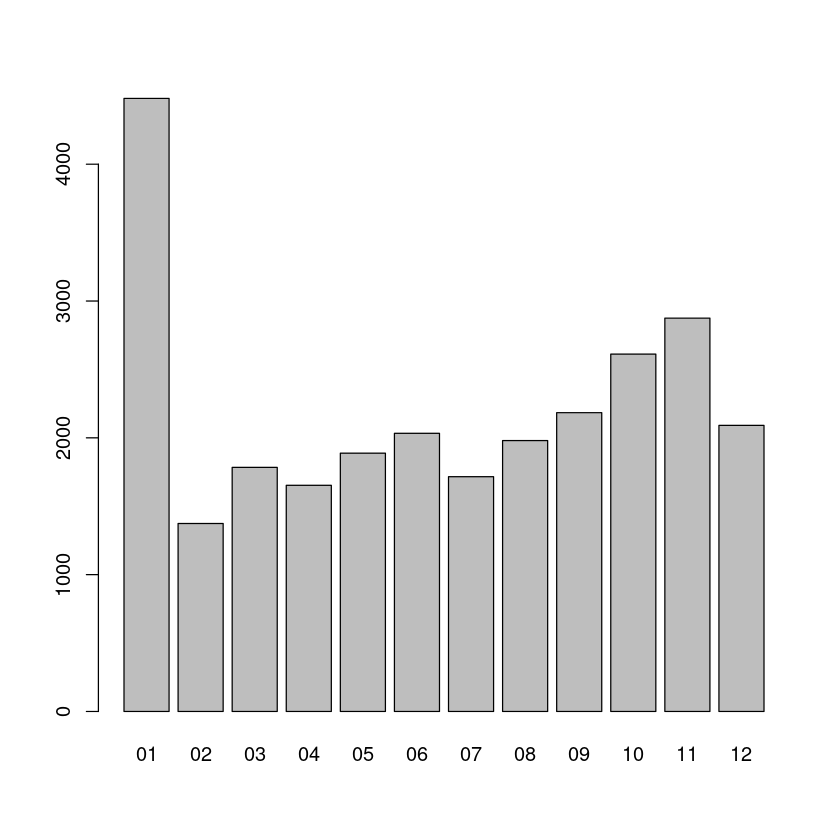

In [9]:
barplot(table(song$month))

En faisant l'histogramme des entrées en fonction du mois, on voit que le mois de janvier semble sur-représenté par rapport aux autres, on décide donc d'attribuer le mois de janvier à tous les N.A. .

In [10]:

library(moder)
#which(is.na(song$month), arr.ind=TRUE)
#song$month
mode <- mode_first(song$month, na.rm = TRUE)
#mode
#which(is.na(song$month))
song[which(is.na(song$month), arr.ind = TRUE),]$month = mode

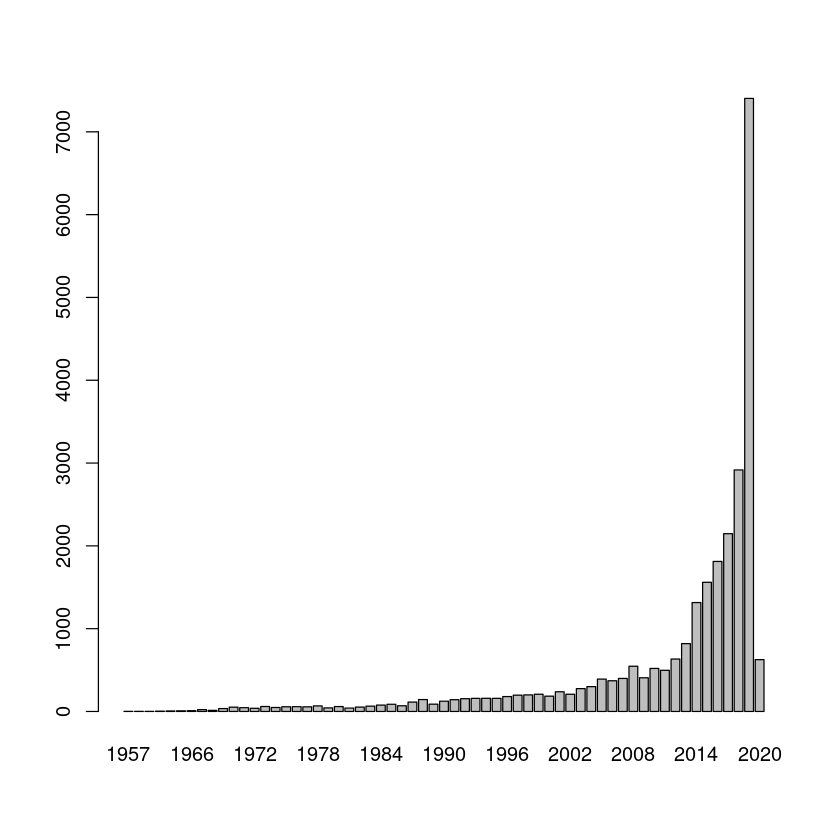

In [11]:
barplot(table(song$year))

On voit que la majorité des musique sont sorties dans les années 2010, on va donc attribuer le mode pour les données manquantes.

On va créer une variable period qui représente la décennie de sortie de la musique.

In [12]:

song$period <- NA 

for (i in 1:nrow(song)){
    if(is.na(song[i,]$year)){
        song[i,]$period <- "2010s"
    }
    else if(song[i,]$year > 2010){
        song[i,]$period <- "2010s"
    }
    else if(song[i,]$year > 2000){
        song[i,]$period <- "2000s"
    }
    else if(song[i,]$year > 1990){
        song[i,]$period <- "1990s"
    }
    else if(song[i,]$year > 1980){
        song[i,]$period <- "1980s"
    }
    else if(song[i,]$year > 1970){
        song[i,]$period <- "1970s"
    }
    else if(song[i,]$year > 1960){
        song[i,]$period <- "1960s"
    }
    else{
        song[i,]$period <- "1950s"
    }
}
song$month<-as.factor(song$month)
song$year<-as.factor(song$year)
song$period <- as.factor(song$period)

In [13]:
mode <- mode_first(song$year, na.rm = TRUE)
song$year[which(is.na(song$year), arr.ind = TRUE)] = mode

In [14]:
library(ggplot2)
histo_genre <- ggplot(song,aes(x=playlist_genre))+
  geom_histogram(stat="count")+
  labs(title = "Distribution des genres des musiques")

histo_year <- ggplot(song,aes(x=year))+
    geom_histogram(stat="count")+
    labs(title = "Distribution des années de sortie des musiques")+
    scale_x_discrete(breaks = levels(factor(song$year))[seq(1, length(levels(factor(song$year))), by = 10)])

histo_month <- ggplot(song,aes(x=month))+
    geom_histogram(stat="count",fill='blue')+
    labs(title = "Distribution des mois de sortie des musiques")

histo_popularity <- ggplot(song,aes(x=track_popularity))+
    geom_histogram(stat="count")+
    labs(title = "Distribution des popularités des musiques")

histo_danceability <- ggplot(song,aes(x=danceability))+
    geom_histogram(bins=50)+
    labs(title = "Distribution de la danceabilité des musiques")

histo_energy <- ggplot(song,aes(x=energy))+
    geom_histogram(bins=50)+
    labs(title = "Distribution de l'energie des musiques")

histo_key <- ggplot(song,aes(x=key))+
    geom_histogram(bins=50,stat='count')+
    labs(title = "Distribution de la clé des musiques")

histo_loudness <- ggplot(song,aes(x=loudness))+
    geom_histogram(bins=50)+
  labs(title = "Distribution de la force sonore des musiques")

histo_mode  <- ggplot(song,aes(x=mode))+
    geom_histogram(bins=50,stat='count')+
    labs(title = "Distribution de du mode des musiques")

histo_speechiness <- ggplot(song,aes(x=speechiness))+
    geom_histogram(bins=50)+
    labs(title = "Distribution de la vocabilité des musiques")

histo_instrumentalness <- ggplot(song,aes(x=instrumentalness))+
    geom_histogram(bins=50)+
    labs(title = "Distribution de l'intrumentabilité des musiques")

histo_liveness <- ggplot(song,aes(x=liveness))+
    geom_histogram(bins=50)+
    labs(title = "Distribution de la liveness des musiques")

histo_valence <- ggplot(song,aes(x=valence))+
    geom_histogram(bins=50)+
    labs(title = "Distribution de la valence des musiques")

histo_tempo <- ggplot(song,aes(x=tempo))+
    geom_histogram(bins=50)+
    labs(title = "Distribution du tempo des musiques")

histo_duration_s <- ggplot(song,aes(x=duration_s))+
    geom_histogram(bins=50)+
    labs(title = "Distribution de la durée des musiques")

Warning message in geom_histogram(stat = "count"):
“Ignoring unknown parameters: `binwidth`, `bins`, and `pad`”
Warning message in geom_histogram(stat = "count"):
“Ignoring unknown parameters: `binwidth`, `bins`, and `pad`”
Warning message in geom_histogram(stat = "count", fill = "blue"):
“Ignoring unknown parameters: `binwidth`, `bins`, and `pad`”
Warning message in geom_histogram(stat = "count"):
“Ignoring unknown parameters: `binwidth`, `bins`, and `pad`”
Warning message in geom_histogram(bins = 50, stat = "count"):
“Ignoring unknown parameters: `binwidth`, `bins`, and `pad`”
Warning message in geom_histogram(bins = 50, stat = "count"):
“Ignoring unknown parameters: `binwidth`, `bins`, and `pad`”


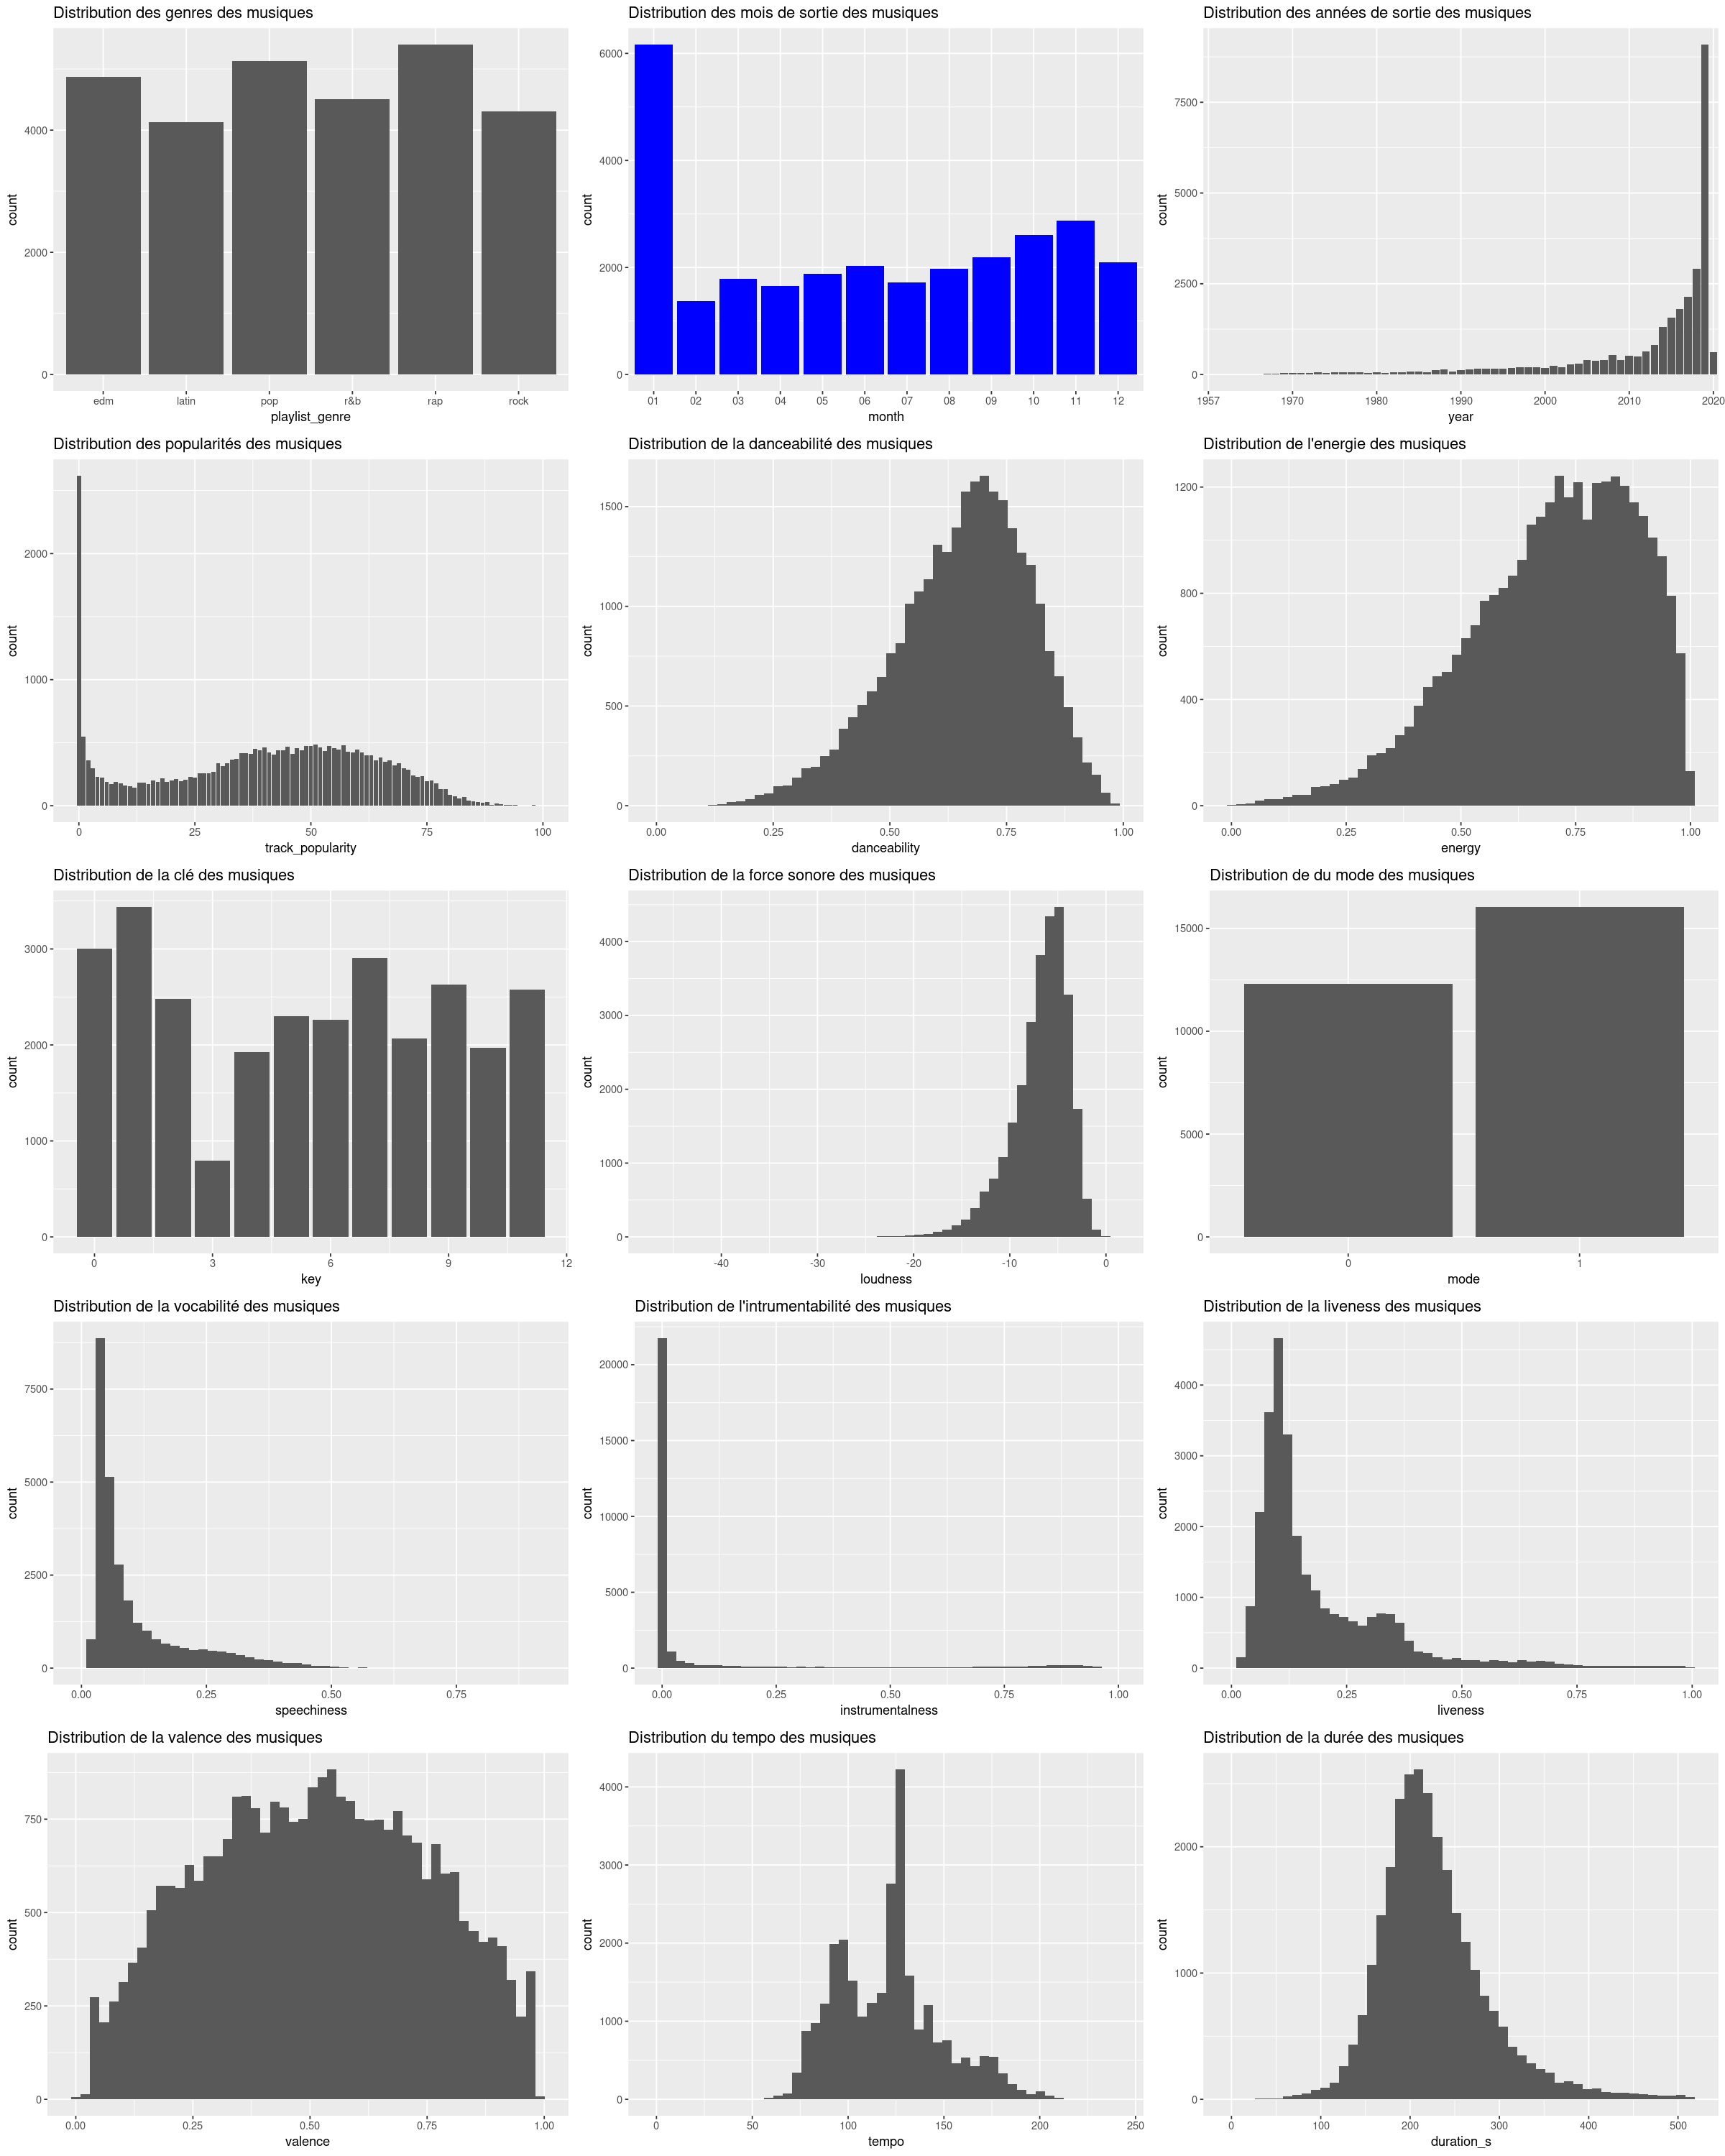

In [15]:
library("gridExtra")
options(repr.plot.width=20, repr.plot.height=25)
grid.arrange(histo_genre,histo_month,histo_year, histo_popularity,histo_danceability,histo_energy,histo_key,histo_loudness,histo_mode,histo_speechiness, histo_instrumentalness, histo_liveness,histo_valence,histo_tempo,histo_duration_s, ncol=3)

Registered S3 method overwritten by 'GGally':
  method from   
  +.gg   ggplot2

corrplot 0.92 loaded



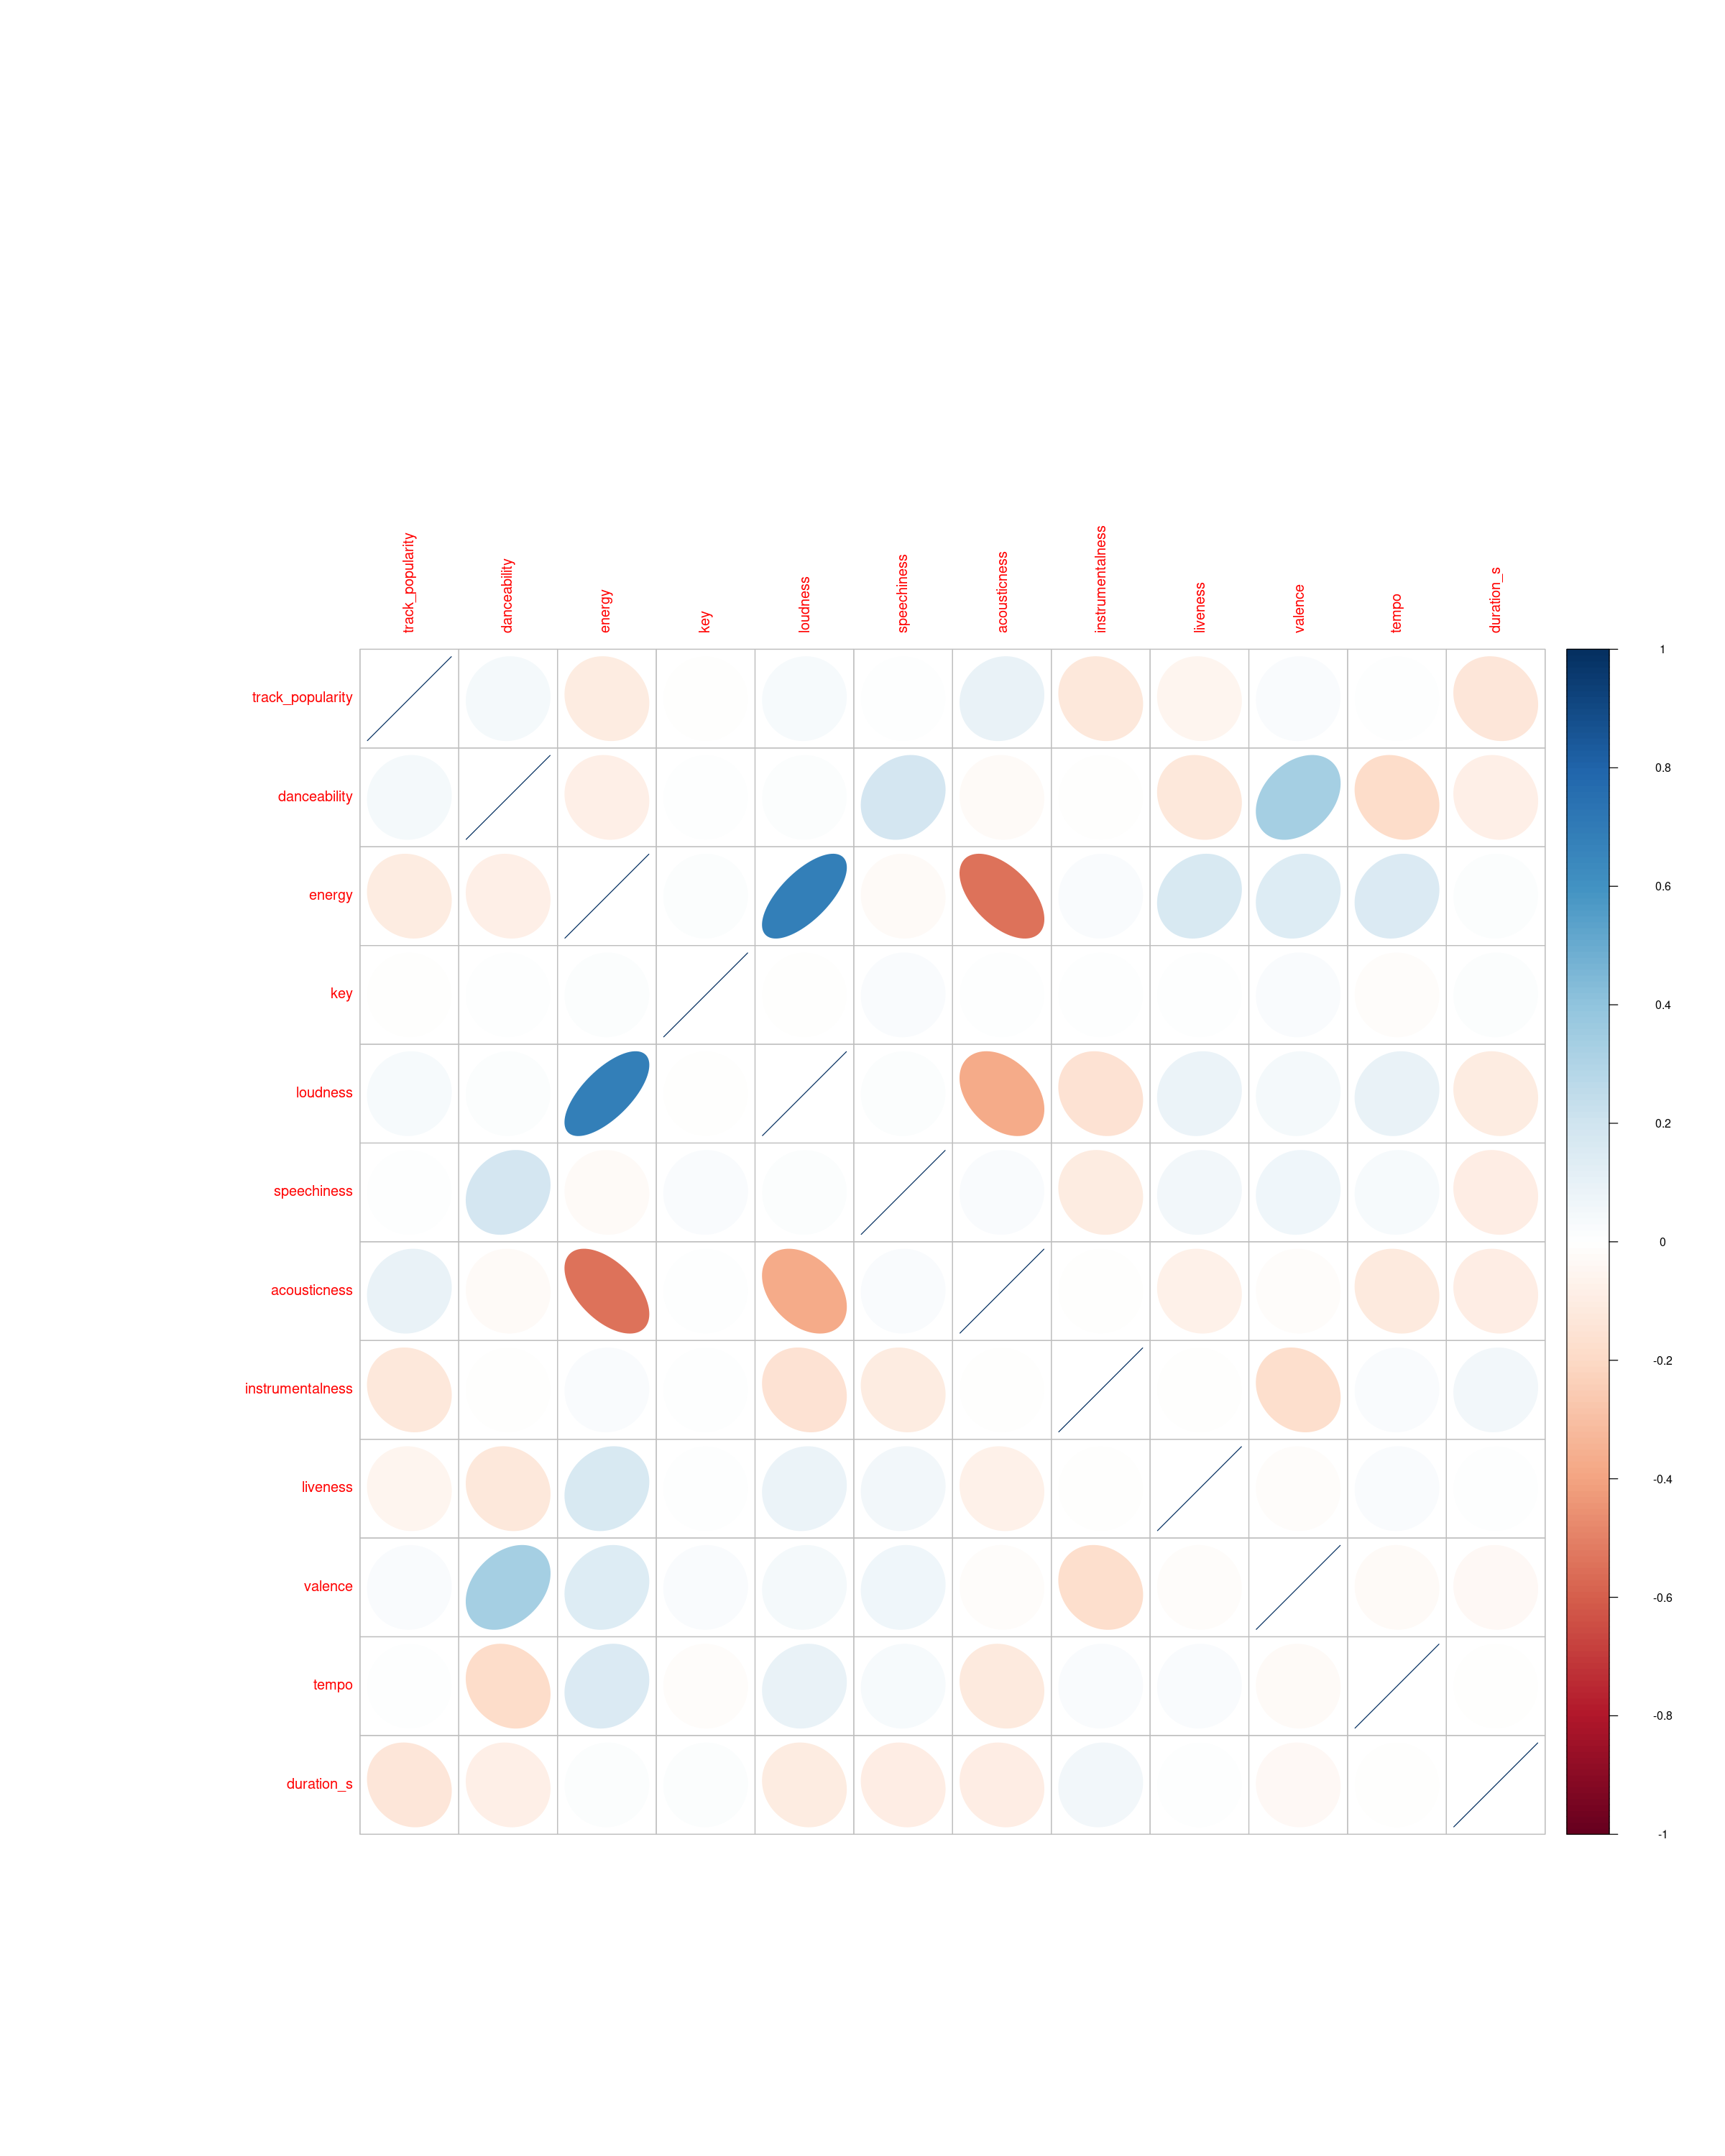

In [16]:
library(ggplot2)
library(GGally)
library(corrplot)
song_num <- song[,c(2,7:10,12:18)]
corrplot(cor(song_num), method = "ellipse")
#ggpairs(song, columns = c(2, 5, 7, 8, 9, 10, 11, 12,13,14,15,16,17,18,19), columnLabels = c("track_popularity", "playlist_genre", "danceability", "energy", "key", "loudness", "mode", "speechiness", "acousticness", "instrumentalness", "liveness", "valence", "tempo", "duration_s", "month"))

Energy and loudness are strongly positively correlated (understandable).
Energy and acousticness are negatively correlated. Loudness and acousticness are mildly negatively correlated. It is understandable because when a song gets louder, it often becomes harder to distinguish the different instruments and sounds.
Danceability and valence are mildly positively correlated. Thus a song that is easier to dance to is one that is more likely to impulse a positive feeling to its listeners.

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


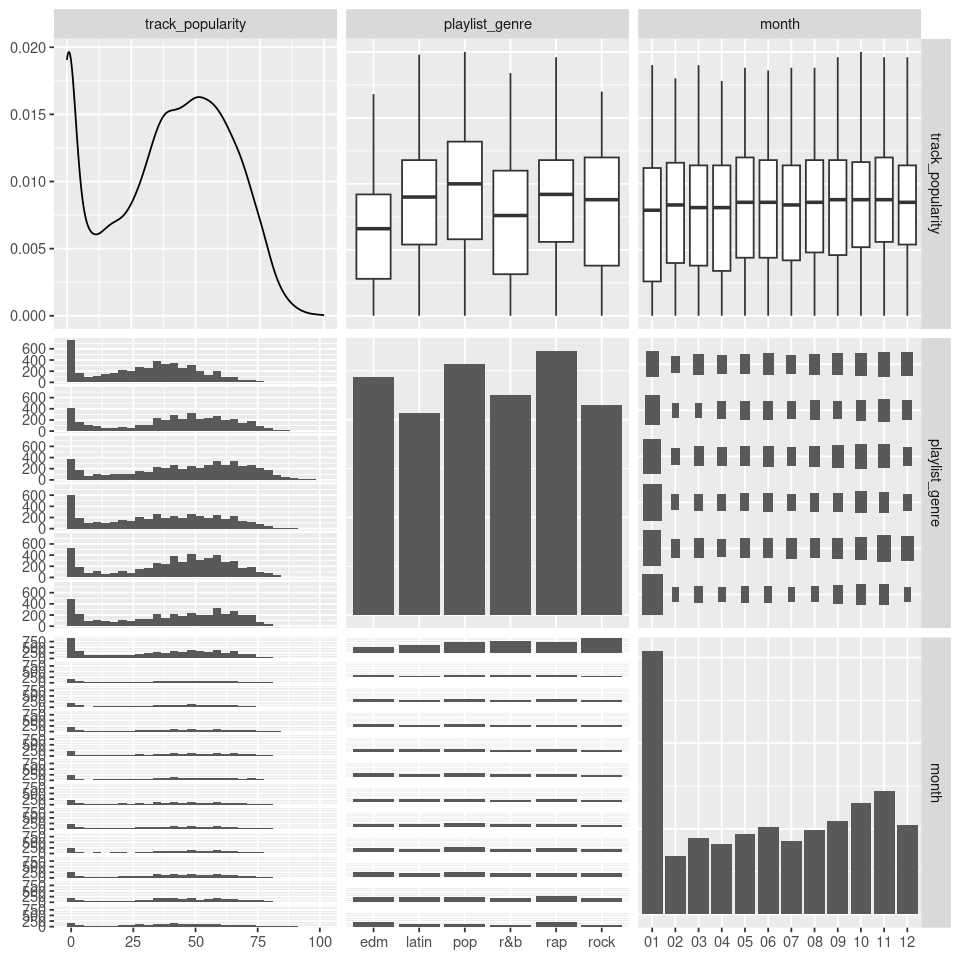

In [17]:
options(repr.plot.width=8,repr.plot.height=8)
ggpairs(song,columns=c(2, 5, 19), cardinality_threshold = 15, progress = FALSE)
#ggpairs(song,columns=c(2, 9:12), cardinality_threshold = 65, progress = FALSE)
#ggpairs(song,columns=c(2, 13:16), cardinality_threshold = 65, progress = FALSE)

We see that pop is the most popular genre in average, but the difference is slight. EDM is the least popular genre.
There does not seem to be a clear relationship between month and track popularity.

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


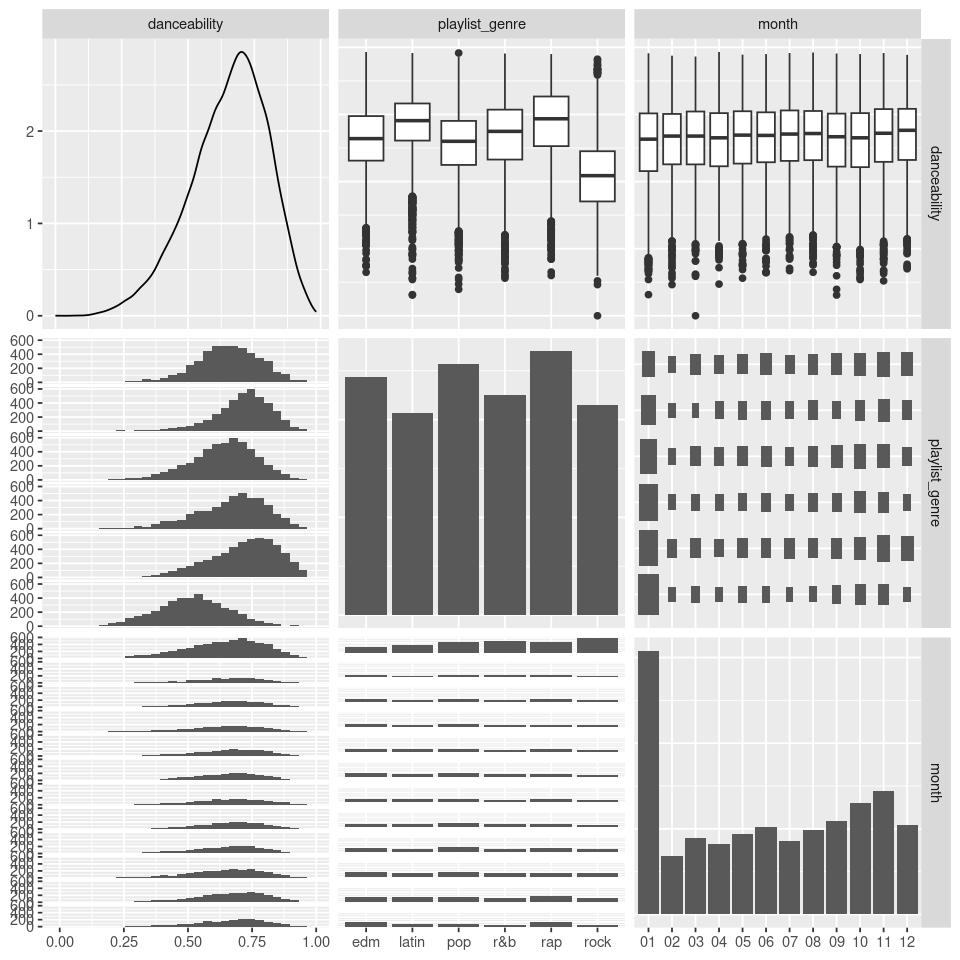

In [18]:
ggpairs(song,columns=c(7, 5, 19), cardinality_threshold = 15, progress = FALSE)

Latin and rap are the most danceable genres, rock has the worst 

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


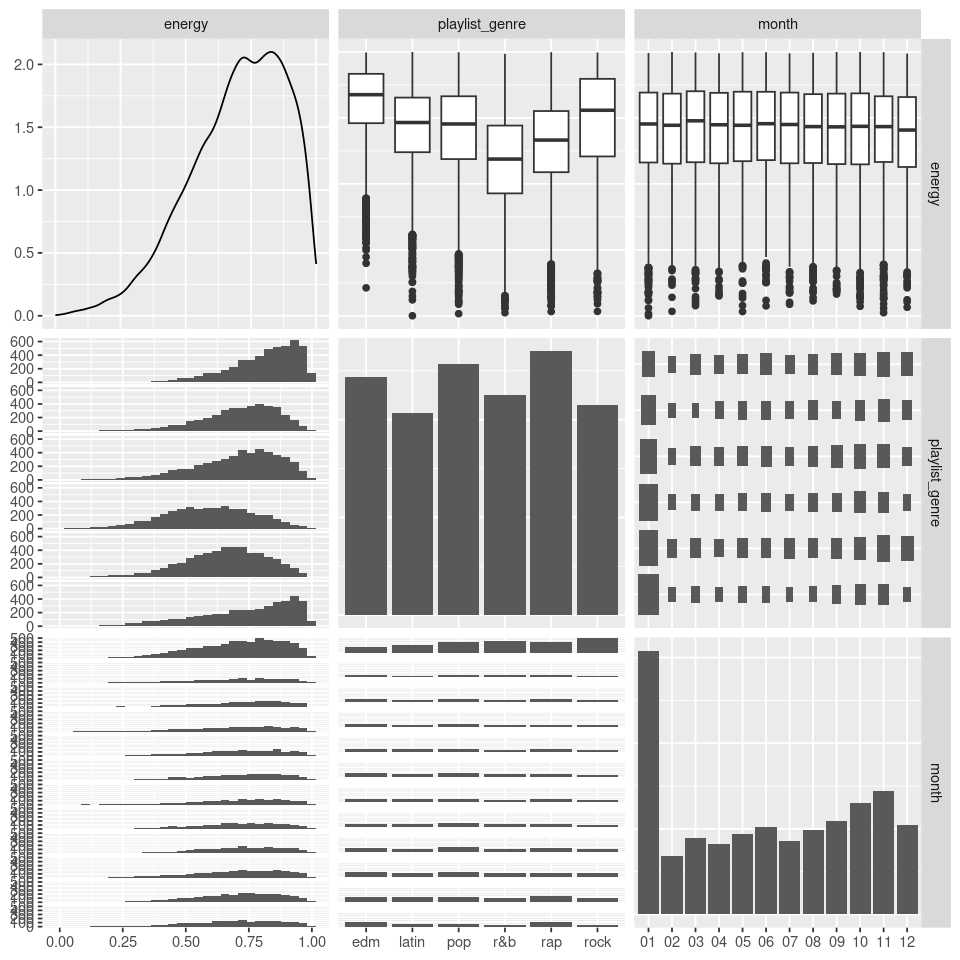

In [19]:
ggpairs(song,columns=c(8, 5, 19), cardinality_threshold = 15, progress = FALSE)

EDM is the genre with the most energy, r&b has the least energy.

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


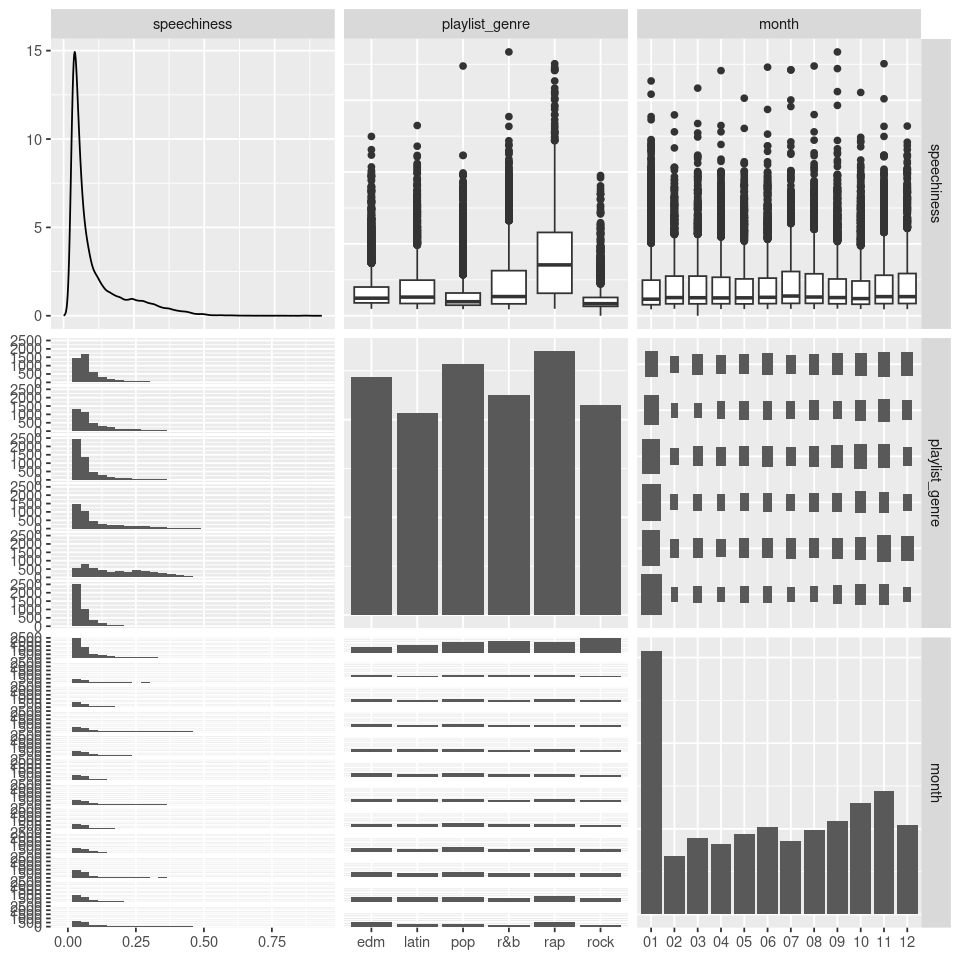

In [20]:
ggpairs(song,columns=c(12, 5, 19), cardinality_threshold = 15, progress = FALSE)

Rap has significantly more speechiness than other genres, which is understandable as it is more focused on speech.

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


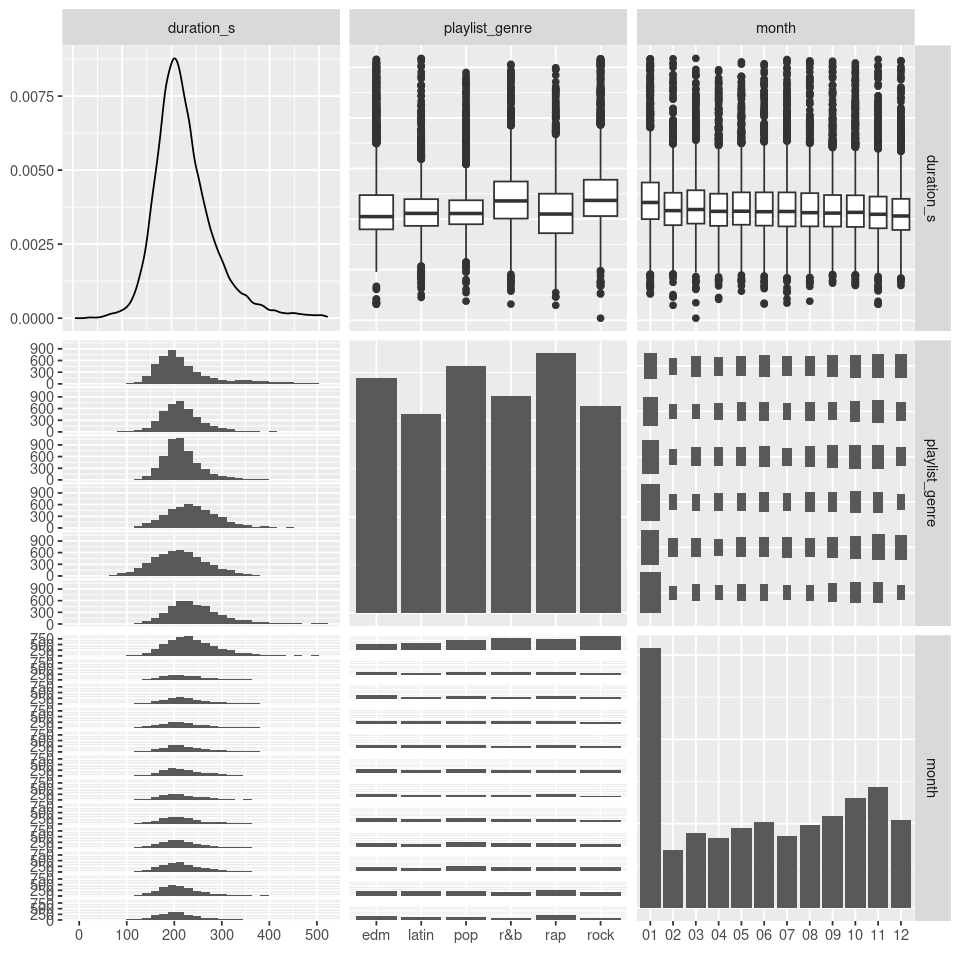

In [21]:
ggpairs(song,columns=c(18, 5, 19), cardinality_threshold = 15, progress = FALSE)

## ACP

In [22]:
library("FactoMineR")
library("factoextra")
library(reshape2)

Welcome! Want to learn more? See two factoextra-related books at https://goo.gl/ve3WBa


Attachement du package : ‘reshape2’


L'objet suivant est masqué depuis ‘package:tidyr’:

    smiths




In [23]:
res.pca <- PCA(song,quali.sup=c(1,3:6,11,19:21),scale.unit=TRUE,ncp=8)

On a décidé de garder la variable key dans l'ACP car même si le nombre de valeurs est fini, elles sont ordonnées. Key représente la tonalité de la musique, augmenter de 1 la key augmente le ton de 0.5 .

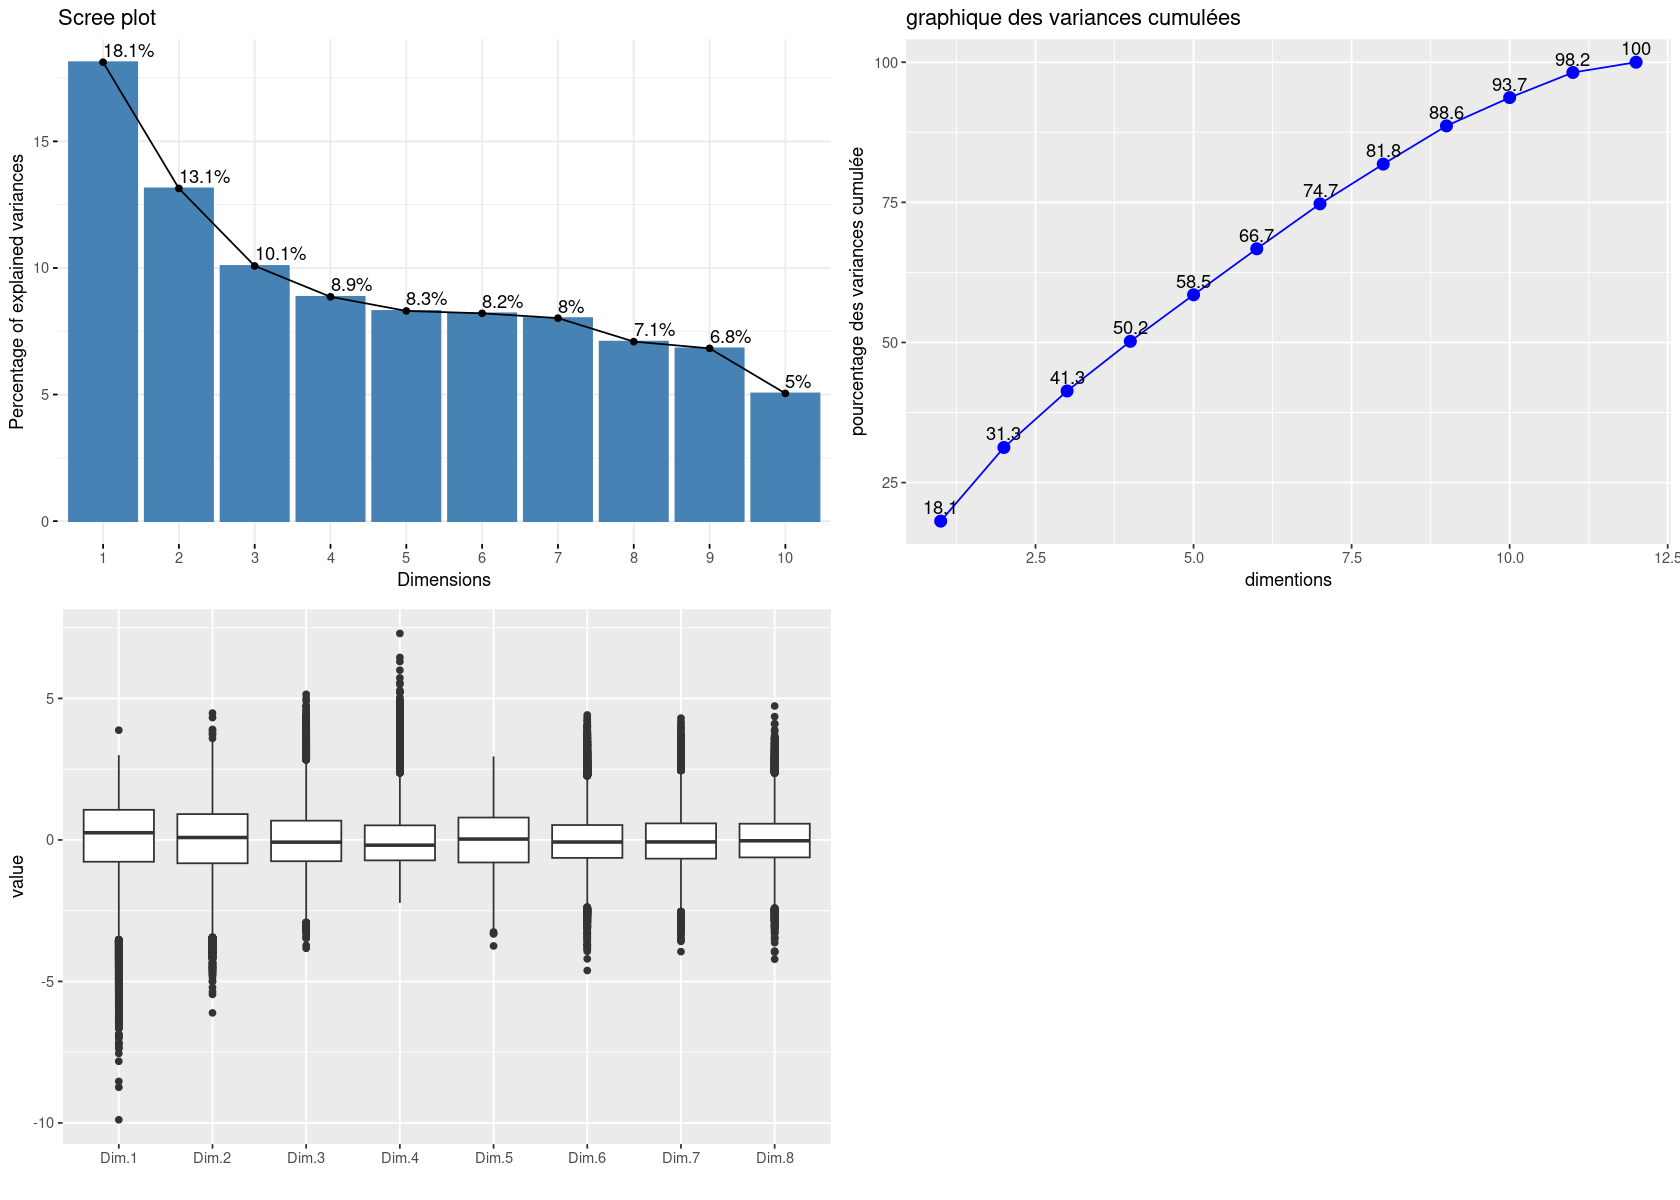

In [24]:
options(repr.plot.width=14,repr.plot.height=10)
#décroissance valeurs propres
g1<-fviz_eig(res.pca,addlabels=TRUE)

#variances cumulées
cum_var <- cumsum(res.pca$eig[,2])

# Graphique avec ggplot2
g2<-ggplot(data.frame(Dimension = 1:length(cum_var), Variance = cum_var), aes(x = Dimension, y = Variance)) +
    geom_point(size = 3, color = "blue") +
    geom_line(color = "blue") +
    labs(title = "graphique des variances cumulées",x='dimentions', y = "pourcentage des variances cumulée") +
    geom_text(aes(y = cum_var, label = round(cum_var, 1)), vjust = -0.5, color = "black") 

g3<-ggplot(melt(res.pca$ind$coord),aes(x=Var2,y=value))+
  geom_boxplot()+
  xlab("")
grid.arrange(g1,g2,g3,ncol=2)

Pour atteindre 80% de la variance, on a besoin de garder 8 composantes. Ce n'est pas très performant, la dimension n'est pas vraiment réduite.

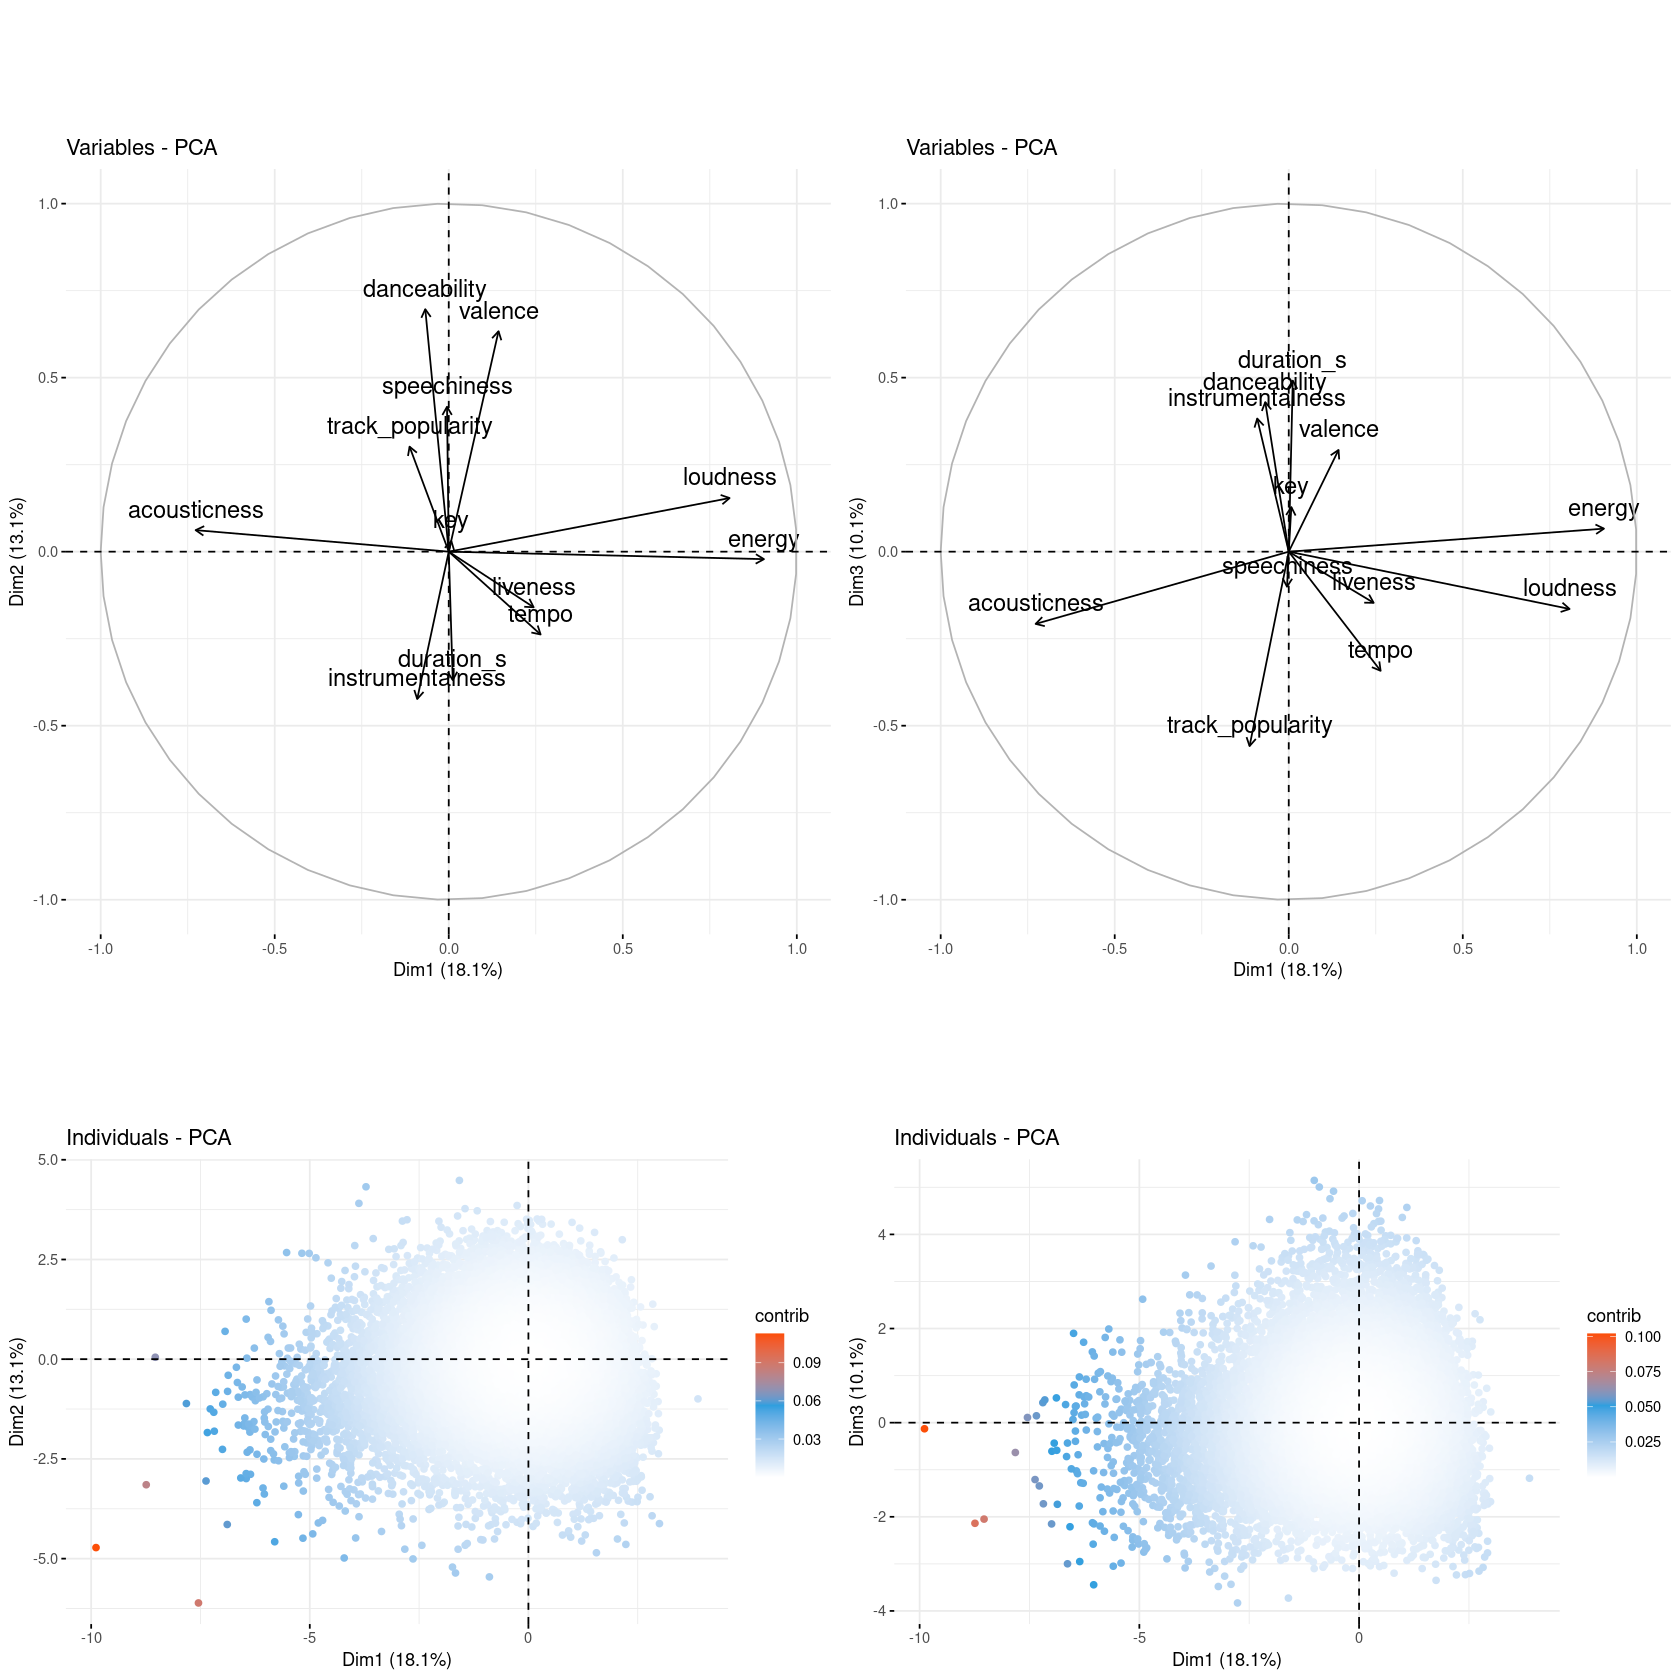

In [25]:
options(repr.plot.width=14,repr.plot.height=14)
g4<-fviz_pca_var(res.pca,labelsize = 5)
g5<-fviz_pca_ind(res.pca, col.ind="contrib",label="none",gradient.cols = c("white", "#2E9FDF", "#FC4E07" ))
g6<-fviz_pca_var(res.pca,axes=c(1,3),labelsize = 5)
g7<-fviz_pca_ind(res.pca,col.ind="contrib",label="none",gradient.cols = c("white", "#2E9FDF", "#FC4E07" ),axes=c(1,3))

grid.arrange(g4,g6,g5,g7,ncol=2,nrow=2,heights=c(2,1))

In [26]:
contrib_ind<-res.pca$ind$contrib[,c(1,2)]
top_ind<-order(contrib_ind,decreasing=TRUE)[1:3]
song[top_ind,]

,track_artist,track_popularity,track_album_name,playlist_name,playlist_genre,playlist_subgenre,danceability,energy,key,loudness,⋯,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_s,month,year,period
,<fct>,<int>,<fct>,<fct>,<fct>,<fct>,<dbl>,<dbl>,<int>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<fct>,<fct>
15578,The Sleep Specialist,51,Jungle And Forest Sounds,Tropical Nights,latin,tropical,0.211,0.4250,7,-46.448,⋯,0.0542,0.880,6.13e-01,0.184,0.0122,116.884,181.204,01,2017,2010s
21429,Chico DeBarge,0,Long Time No See,90s R&B - The BET Planet Groove/Midnight Love Mix,r&b,new jack swing,0.220,0.0286,1,-34.283,⋯,0.0562,0.943,0.00e+00,0.218,0.0383,128.899,31.893,11,1997,1990s
15585,Nature Sounds,50,"Nature Sounds with Birdsong, Waves, Forest, Garden, And More Beautiful Sounds of the Earth!",Tropical Nights,latin,tropical,0.318,0.1790,8,-35.427,⋯,0.4790,0.877,3.82e-05,0.226,0.4220,97.368,45.000,04,2015,2010s


Les 3 individus qui contribuent plus que les autres dans les deux premiers plans factoriels ne sont peut-être pas des outliers mais des musiques qui sont très bien expliquées par ses plans factoriels car ce sont des musiques très spécifiques/particulières.

La première dimension sépare les musiques plutôt dynamique/énergique et les musiques plus fluides/calmes.
La seconde dimension sépare les musiques populaires/dansantes/courtes et la musique plus classique/instrumentale/longue.
La troisième dimension sépare les musiques populaires et les musiques dansantes type bal.
La quatrième dimension représente les musiques enregistrées en concert.
La cinquième dimension représente la clé de la musique.
Les 3 dernières dimensions sont difficilement interprétables.

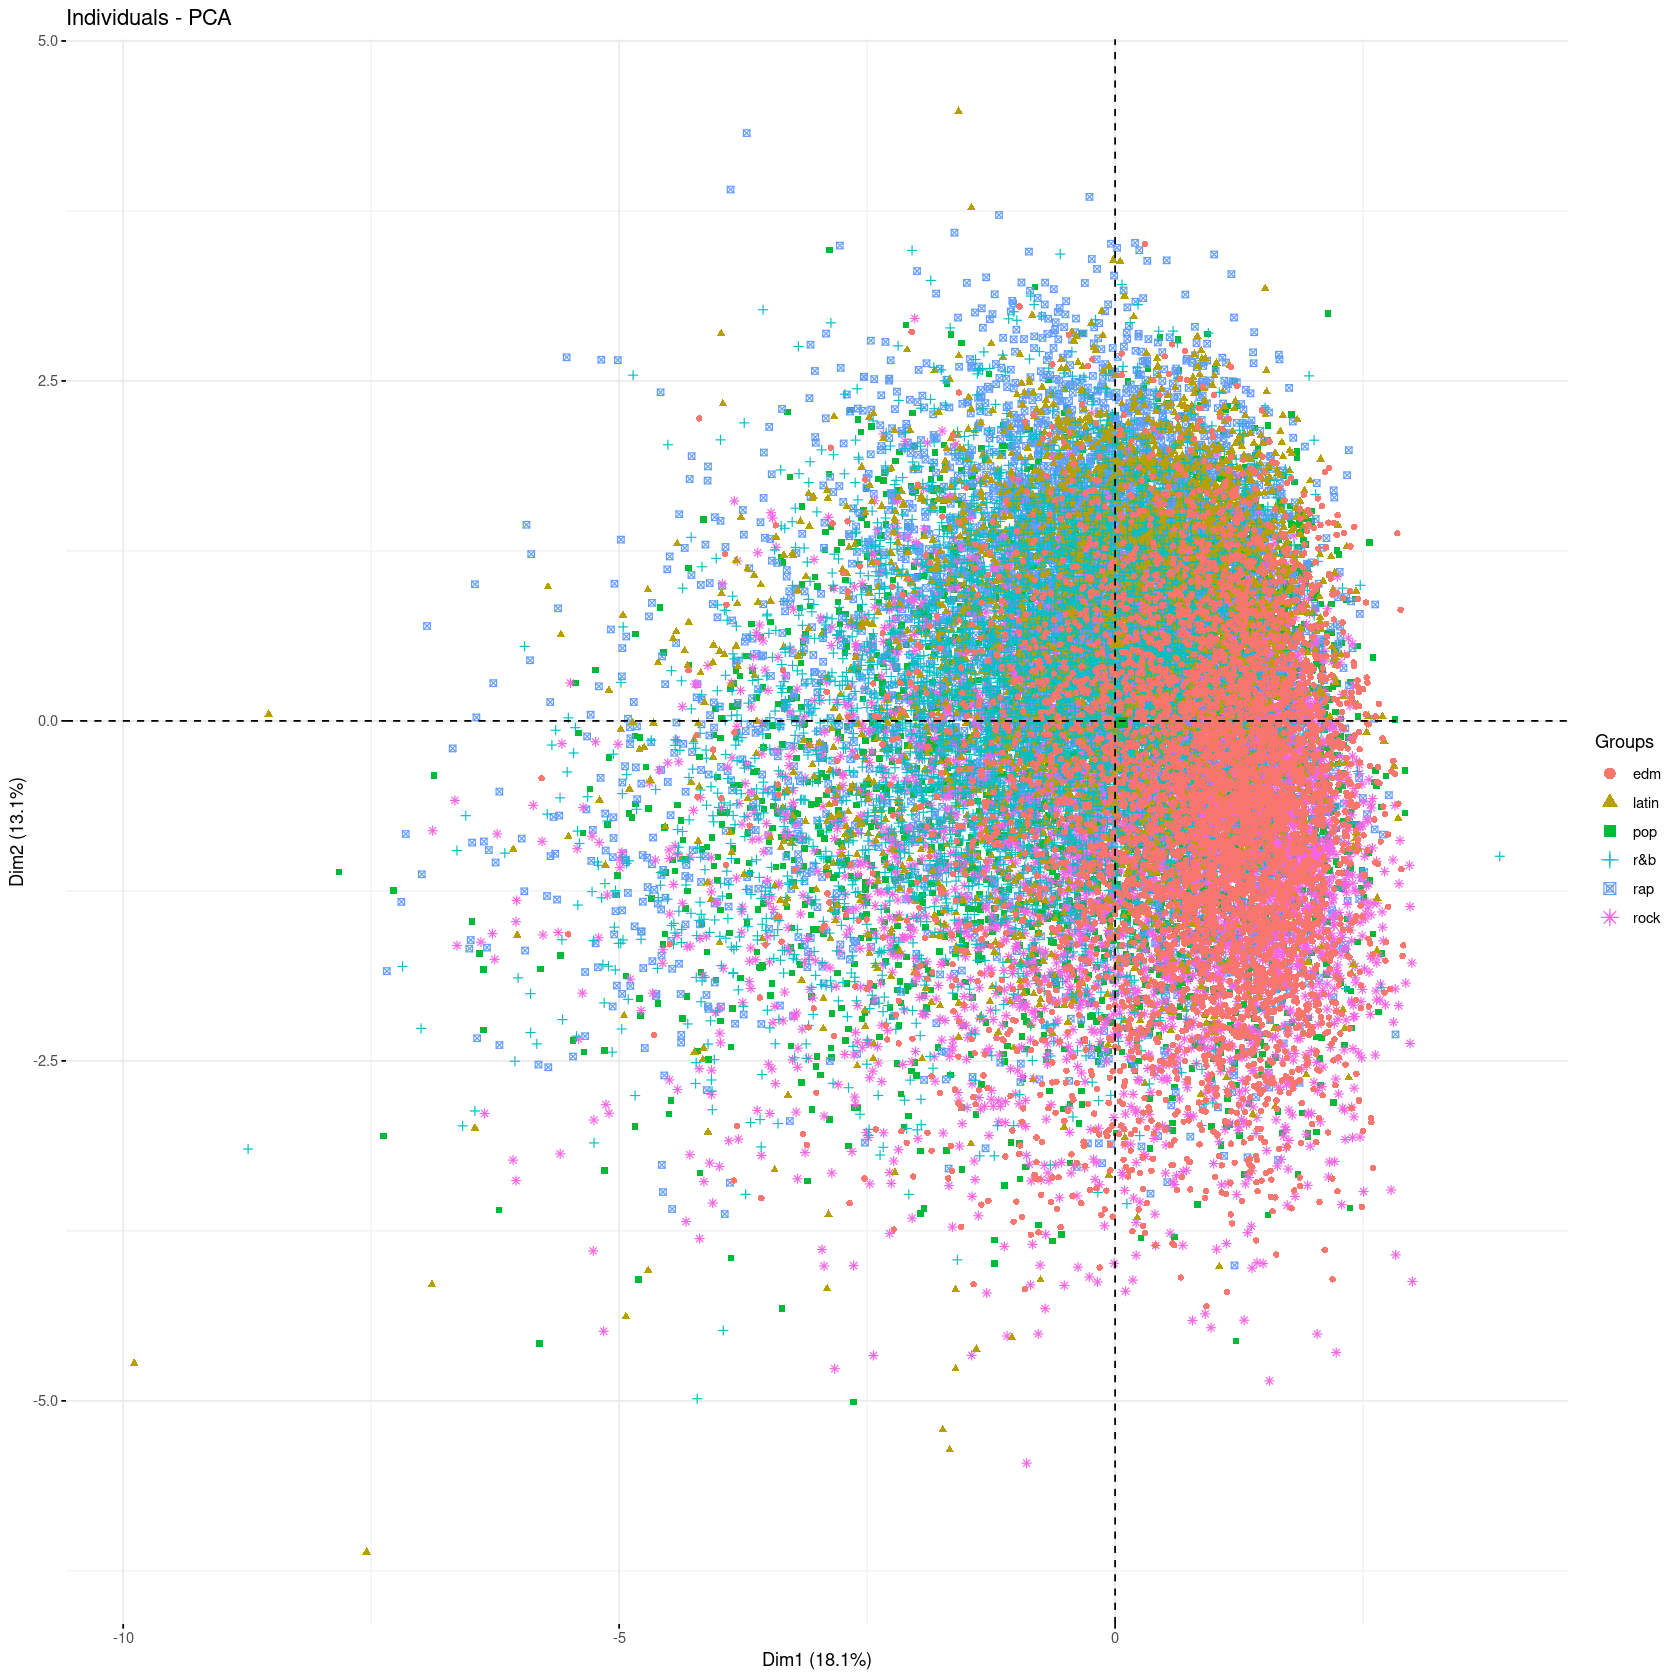

In [28]:
g8<-fviz_pca_ind(res.pca, habillage=song$playlist_genre,label="none")
g8

On voit qu'on ne peut pas discriminer le genre de musique avec uniquement le premier plan factoriel.

## LDA

On va faire une LDA pour essayer de prédire le genre de la playlist dans laquelle se trouve la musique.

Pour facilliter la LDA, on va transformer les variables qualitatives en one-hot. On ne va pas garder que les propriétés physiques de la musique + la popularité. On va supprimer aussi le sous genre car si on ne connait pas le genre on ne connait pas le sous genre.
On va scale les données quantitatives comme pour l'ACP afin que les variables tempo et duration_s ne prennent pas trop d'importance par rapport aux autres variables qui ne prennent pas les mêmes échelles de valeurs.

In [86]:
songLDA<-subset(song, select=-track_artist)
songLDA<-subset(songLDA, select=-track_album_name)
songLDA<-subset(songLDA, select=-playlist_name)
songLDA<-subset(songLDA, select=-playlist_subgenre)
songLDA<-subset(songLDA, select=-month)
songLDA<-subset(songLDA, select=-year)
songLDA<-subset(songLDA, select=-period)
#songLDA<-subset(songLDA, select=-pop)
songLDA[,c(1,3:4,6,8:14)]<-scale(songLDA[,c(1,3:4,6,8:14)])

In [87]:
head(songLDA)

,track_popularity,playlist_genre,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_s
,<dbl>,<fct>,<dbl>,<dbl>,<int>,<dbl>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1.1251184,pop,0.6490454,1.1859272,6,1.3778591,1,-0.48406214,-0.3374649,-0.3918495,-0.80605901,0.03249277,0.03998519,-0.5209548
2,1.1673135,pop,0.4981442,0.6355434,11,0.6088647,1,-0.68884578,-0.4703109,-0.3737468,1.06515899,0.77925866,-0.77857938,-1.0473674
3,1.2938987,pop,0.1483278,1.2676674,1,1.1150507,0,-0.32901166,-0.4388947,-0.3917493,-0.51931426,0.43787997,0.11314551,-0.8179030
4,0.8719479,pop,0.4432710,1.2622181,7,1.0011012,1,-0.05791713,-0.6664383,-0.3918089,0.08368366,-0.99591055,0.03701722,-0.9410666
5,1.2517037,pop,-0.0231509,0.7336316,1,0.7066768,1,-0.70249802,-0.4348554,-0.3918495,-0.69059133,0.91581014,0.11195832,-0.6143057
6,1.1673135,pop,0.1483278,1.2022753,8,0.4718618,1,0.18587292,-0.4366506,-0.3918495,-0.30762350,0.31839742,0.14928047,-1.0400166


In [88]:
set.seed(42)
sample<-sample(c(TRUE,FALSE),nrow(songLDA),replace=TRUE,prob=c(0.7,0.3))
train<-songLDA[sample,]
test<-songLDA[!sample,]
res.lda<-lda(playlist_genre~.,data=train)

In [89]:
lda_pred<-predict(res.lda,test)

In [90]:
library(caret)
conf_matrix <- confusionMatrix(lda_pred$class, factor(test$playlist_genre))
print(conf_matrix)

Confusion Matrix and Statistics

          Reference
Prediction edm latin pop r&b rap rock
     edm   825   151 171  55 143  106
     latin 110   365 205 172 170   83
     pop   264   260 605 188 167  170
     r&b    66   140 185 497 151  139
     rap   130   218 144 265 901   20
     rock   72    86 277 149  68  775

Overall Statistics
                                          
               Accuracy : 0.4672          
                 95% CI : (0.4566, 0.4779)
    No Information Rate : 0.1884          
    P-Value [Acc > NIR] : < 2.2e-16       
                                          
                  Kappa : 0.3588          
                                          
 Mcnemar's Test P-Value : < 2.2e-16       

Statistics by Class:

                     Class: edm Class: latin Class: pop Class: r&b Class: rap
Sensitivity             0.56237      0.29918    0.38122    0.37481     0.5631
Specificity             0.91090      0.89825    0.84810    0.90498     0.8873
Pos Pred Value   

On obtient une précision de 47% sur la classification ce qui n'est pas très bon.

Essayer QDA, LDA sur espace d'ACP